# Coherence discovery

In this example we show how Koopman theory can be used to analyze the coherence between observables of a dynamical system. We study a simple 2D signal composed by a sum of a small number of sinusoidal functions. Using Koopman theory and its implementation in `kooplearn`, we aim to detect presence (_coherence_) and sinchrnonicity of two components of a signal at different frequencies. 

In [1]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
from kooplearn.abc import BaseModel
import pandas as pd

np.random.seed(0)

## Data generation 

We now generate a synthetic signal for our analysis using the _gen_signal_ function, as above. Our dataset will have $10000$ points of the 2D signal's trajectory, all observed at a regular interval of one $dt = 0.01 \, {\rm s}$. The first component of a signal frequencies 2Hz, 8Hz, 13Hz and 15Hz, while the second one has two times smaller amplitude and has frequencies 5Hz, 7Hz and 8Hz with phase delays of $0$, $\pi/2$ and $4\pi/3$.

In [2]:
def gen_signal(i, freqs, phases = None):
    if phases == None: 
        phases = np.zeros_like(freqs)
    X = np.zeros(i.shape[0])
    for fp in np.vstack((freqs, phases)).T:
        X += np.sin(fp[1] + i*fp[0]*2*np.pi)
    return X

N = 10000
dt = 0.01

i = np.arange(N)*dt

# First component
X1 = gen_signal(i, [2, 8, 13, 15],[0,0,0,0])
    
# Second component
X2 = gen_signal(i, [5, 7, 8],[0, np.pi/2, -4*np.pi/3])

# Mixing the regimes
X_no_noise = np.vstack((X1,X2/2)).T

The signal is then perturbed by an additive noise with a small variance compared to the values taken by the signal.

In [3]:
noise = 0.3*np.random.randn(N,2)

X = X_no_noise + noise

Let us plot the trajectories of our dataset:

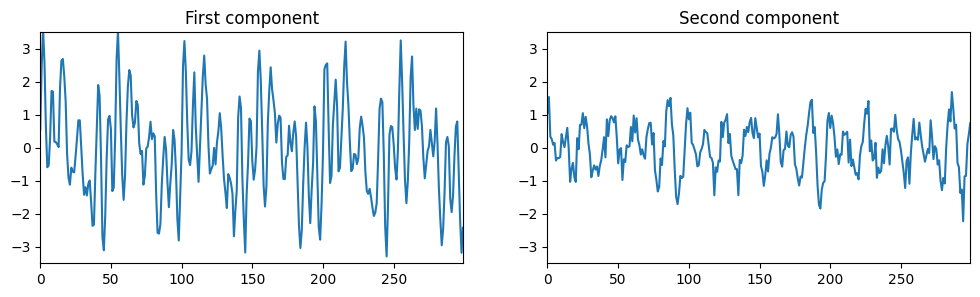

In [4]:
plt.figure(figsize=(12,3))
plt.subplot(1, 2, 1)
plt.plot(X[:300,0])
plt.ylim((-3.5, 3.5))
plt.margins(x = 0)
plt.title('First component')

plt.subplot(1, 2, 2)
plt.plot(X[:300,1])
plt.ylim((-3.5, 3.5))
plt.title('Second component')
plt.margins(x = 0)
plt.show()

## Koopman model

We now show that fitting a Koopman operator enables a complete characterization of the dynamics. The first step to fit a Koopman model with kooplearn is to organize the data according to the [paradigm based on context windows](kooplearn_data_paradigm). Since in this case we have a single trajectory we can use the utility function {meth}`kooplearn.data.traj_to_contexts`.

In [5]:
from kooplearn.data import traj_to_contexts

T = 1000  #memory of past states  
dataset = traj_to_contexts(X, context_window_len = T+1)

n_pts, ctx_len, dim = dataset.shape
print(f"Dataset has {n_pts} context windows of size {ctx_len} for a system of dimension {dim}.")

Dataset has 9000 context windows of size 1001 for a system of dimension 2.


We now take a small subset of the full dataset and fit a Koopman model on it. For this example we will use kernel methods, and specifically the _Reduced Rank Regression_ described in {footcite:t}`Kostic2022`. We use a combination of linear and Gaussian (i.e. RBF) kernels, the latter of which with a length-scale corresponding to the median heuristic.

In [6]:
from sklearn.gaussian_process.kernels import DotProduct, RBF
from kooplearn.models.kernel import Kernel
from scipy.spatial.distance import pdist

train_contexts = dataset[:1000]

median_heuristic_lengthscale = np.median(pdist(X.reshape(-1, 1)))*50
kernel = 0.5*(DotProduct() + RBF(length_scale=median_heuristic_lengthscale))
model = Kernel(reduced_rank= True, kernel=kernel, rank=20, tikhonov_reg=1e-8, svd_solver="randomized")
model.fit(train_contexts)

The dominant frequencies of the dynamics $\omega_{i}$ are related to the Koopman eigenvalues $\lambda_{i}$ by the relation $\omega_{i} = \frac{1}{2\pi \Delta t}\arg (\lambda_{i})$, with $\Delta t$ being the time lag between samples. By evaluating `model.eig()` we can see that the Koopman model perfectly recover the frequencies of the signal:

In [7]:
dominant_frequencies = 100*np.angle(model.eig())/(2*np.pi)
for f in dominant_frequencies:
    if f > 0: # Koopman eigenvalues come in complex-conjugate paris. Discarting the eigenvalues with negative imaginary part.
        print(f"Found {f:.3f} Hz as a dominant freqency of the dynamics")

Found 50.000 Hz as a dominant freqency of the dynamics
Found 46.703 Hz as a dominant freqency of the dynamics
Found 26.329 Hz as a dominant freqency of the dynamics
Found 15.000 Hz as a dominant freqency of the dynamics
Found 13.000 Hz as a dominant freqency of the dynamics
Found 8.000 Hz as a dominant freqency of the dynamics
Found 7.000 Hz as a dominant freqency of the dynamics
Found 4.999 Hz as a dominant freqency of the dynamics
Found 2.000 Hz as a dominant freqency of the dynamics


The Koopman model can be used also to forecast the signal (and any observable of it). By taking a validation subset of the full data, we can verify that the forecast is very accurate as well.

In [8]:
val_contexts = dataset[500:700]

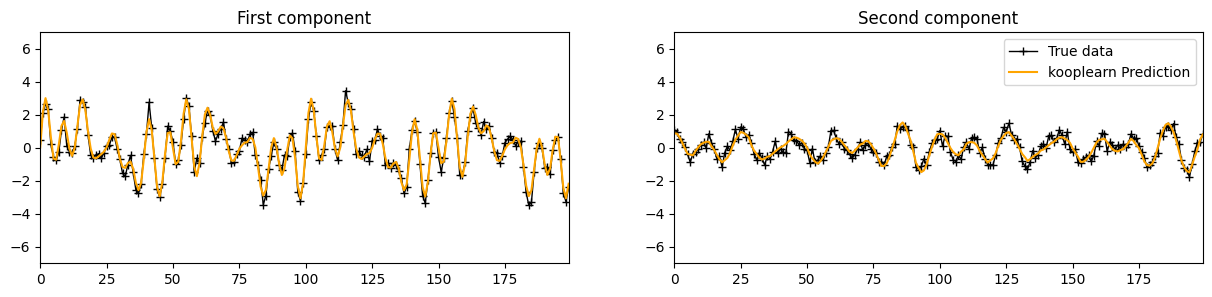

In [9]:
val_contexts = dataset[500:700]

plt.figure(figsize=(15,3))
X_pred = np.squeeze(model.predict(val_contexts))
X_true = np.squeeze(val_contexts.lookforward(model.lookback_len))

plt.subplot(1, 2, 1)
plt.title('First component')
plt.plot(X_true[:,0], '+-', label='True data', lw=1, color='k')
plt.plot(X_pred[:,0], label='kooplearn Prediction', color='orange')
plt.ylim((-7, 7))
plt.margins(x=0)

plt.subplot(1, 2, 2)
plt.title('Second component')
plt.plot(X_true[:,1], '+-', label='True data', lw=1, color='k')
plt.plot(X_pred[:,1], label='kooplearn Prediction', color='orange')
plt.ylim((-7, 7))

plt.margins(x=0)
plt.legend()
plt.show()

## Now let us examine modes of observables

In [10]:
modes, eigs = model.modes(model.data_fit, predict_observables=False)

In [11]:
modes.shape

(20, 1000, 2)

In [12]:
from kooplearn.signal.spectral import compute_mode_info, compute_coherence_metric, compute_phase_delay

In [13]:
weigths = np.abs(train_contexts.data[:,0,:].squeeze()).max(axis=0)

obs_1 = lambda x : (x[...,0]/weigths[0])[...,None]  #/ np.linalg.norm(x,ord = np.inf, axis=-1,keepdims=True)
obs_2 = lambda x : (x[...,1]/weigths[1])[...,None] #/ np.linalg.norm(x,ord = np.inf, axis=-1,keepdims=True)
#obs = lambda x : x / np.linalg.norm(x,axis=-1, keepdims=True)

model.data_fit.observables = {
            'obs_of_interest': obs_1(model.data_fit.data) # must have same size than training dataset, but only the last sample will be used
        }

# model.fit(data_fit)
modes = compute_mode_info(model, use_observables=True, deltat=0.01, xcoord=None)

coh = compute_coherence_metric(model, obs_1, obs_2).squeeze()
delay = compute_phase_delay(model, obs_1, obs_2).squeeze()

In [14]:
modes[["coherence"]]=coh.reshape(-1,1)
modes[["delay"]]=delay.reshape(-1,1)
summary = modes[['eig_num','modulus','frequency',"coherence","delay"]]
filtered = summary[(summary[["modulus"]]>0.5).to_numpy() & (summary[["frequency"]]>0.).to_numpy()]
filtered

,eig_num,modulus,frequency,coherence,delay
9,9,0.993754,15.000255,0.026061,0.301487
11,11,0.995355,13.000028,0.021798,0.542948
13,13,0.997879,7.999881,0.847839,0.664346
15,15,0.928016,6.999615,0.017159,0.001455
17,17,0.924293,4.998622,0.030566,0.163752
19,19,0.996737,1.999923,0.014385,0.362382


Recall signal 2 goes $\frac{4\pi}{3}$ after signal 1, hence phase delay is $-\frac{-4\pi}{3}\frac{1}{2\pi} = 0.66$

In [15]:
summary

,eig_num,modulus,frequency,coherence,delay
0,0,1.160233e-93,50.000000,0.107774,0.000000
1,1,2.727352e-119,-46.702850,0.110838,1.046343
2,2,2.727352e-119,46.702850,0.110838,0.046343
3,3,8.934899e-84,-26.329254,0.984498,0.234317
4,4,8.934899e-84,26.329254,0.984498,1.234317
5,5,1.488110e-120,0.000000,0.386899,-0.500000
6,6,5.492190e-86,0.000000,0.032498,1.000000
7,7,9.082794e-45,0.000000,0.725901,0.000000
8,8,9.937545e-01,-15.000255,0.026061,-0.698513
9,9,9.937545e-01,15.000255,0.026061,0.301487


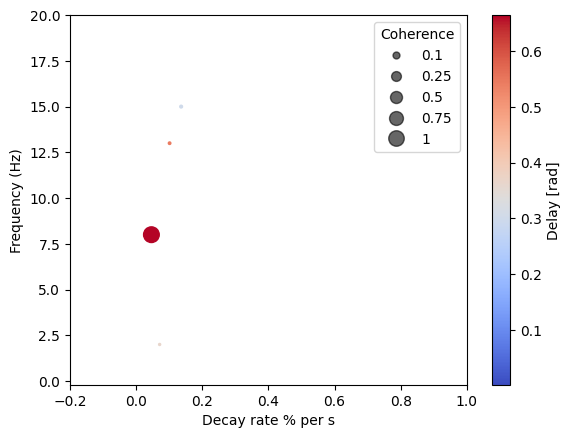

In [16]:
plt.figure()
sc = plt.scatter(np.log(filtered[["modulus"]].to_numpy().flatten()) / (dt * np.log(0.01)), filtered[["frequency"]].to_numpy().flatten(),  c=filtered[["delay"]].to_numpy().flatten(), cmap='coolwarm', s=150*filtered[["coherence"]].to_numpy().flatten())
handles, labels = sc.legend_elements(prop="sizes", alpha=0.6, num=6)
labels = ["0.1", "0.25", "0.5", "0.75", "1"]
plt.legend(handles, labels, loc="upper right", title="Coherence")
plt.colorbar(label='Delay [rad]')
#plt.clim((-1,1))
plt.xlabel('Decay rate % per s')
plt.ylabel('Frequency (Hz)')
plt.xlim((-0.2, 1))
plt.ylim((-0.2, 20))
plt.show()

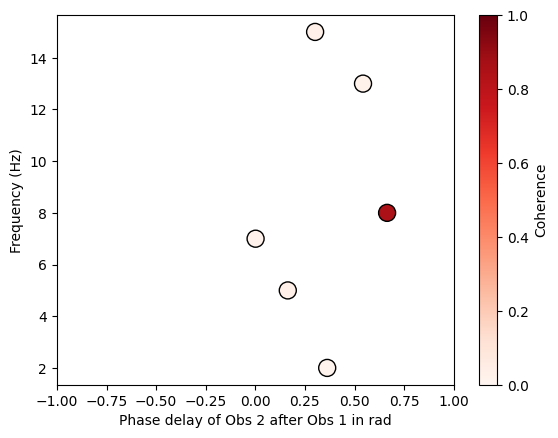

In [17]:
plt.figure()
#sc = plt.scatter(filtered[["delay"]].to_numpy().flatten()/filtered[["frequency"]].to_numpy().flatten(), filtered[["frequency"]].to_numpy().flatten(),  c=filtered[["coherence"]].to_numpy().flatten(), cmap='Reds',marker = "o", s=150, edgecolors='black')
sc = plt.scatter(filtered[["delay"]].to_numpy().flatten(), filtered[["frequency"]].to_numpy().flatten(),  c=filtered[["coherence"]].to_numpy().flatten(), cmap='Reds',marker = "o", s=150, edgecolors='black')
# plt.legend(loc="upper right")
plt.colorbar(label='Coherence')
#plt.xlabel('Delay of Obs 2 after Obs 1 in sec')
plt.xlabel('Phase delay of Obs 2 after Obs 1 in rad')
plt.xlim((-1,1))
plt.ylabel('Frequency (Hz)') 
plt.clim((0,1))
plt.show()